In [1]:
import pandas as pd
import os
df = pd.read_csv("../0_data/1_cleaned/fact_transactions.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# 1. Group by Cohort Month and Cohort Index, and Count Unique Customers
cohort_data = (
    df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID']
      .nunique()
      .reset_index()
)

cohort_data.head()

,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363


In [5]:
# 2. Pivot the Data to Create a Cohort Analysis Table
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 3. Calculate Retention Rates
cohort_size = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(
    cohort_size,
    axis=0
)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,...,0.302618,0.262827,0.302618,0.282723,0.259686,0.255497,0.315183,0.304712,0.407330,0.196859
2010-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,...,0.151436,0.234987,0.198433,0.185379,0.195822,0.242820,0.193211,0.245431,0.057441,NaN
2010-02,1.0,0.237968,0.224599,0.291444,0.245989,0.200535,0.192513,0.286096,0.254011,0.275401,...,0.200535,0.160428,0.163102,0.144385,0.229947,0.229947,0.163102,0.058824,NaN,NaN
2010-03,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.108352,...,0.169300,0.173815,0.155756,0.176072,0.200903,0.212190,0.079007,NaN,NaN,NaN
2010-04,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.105442,0.108844,...,0.156463,0.139456,0.149660,0.180272,0.224490,0.057823,NaN,NaN,NaN,NaN
2010-05,1.0,0.157480,0.169291,0.173228,0.177165,0.255906,0.212598,0.125984,0.059055,0.082677,...,0.125984,0.137795,0.165354,0.153543,0.047244,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174074,0.188889,0.203704,0.229630,0.285185,0.125926,0.088889,0.081481,0.118519,...,0.122222,0.133333,0.203704,0.051852,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.155914,0.182796,0.295699,0.290323,0.139785,0.112903,0.145161,0.145161,0.112903,...,0.172043,0.236559,0.080645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.203704,0.296296,0.320988,0.172840,0.117284,0.098765,0.123457,0.135802,0.129630,...,0.197531,0.067901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


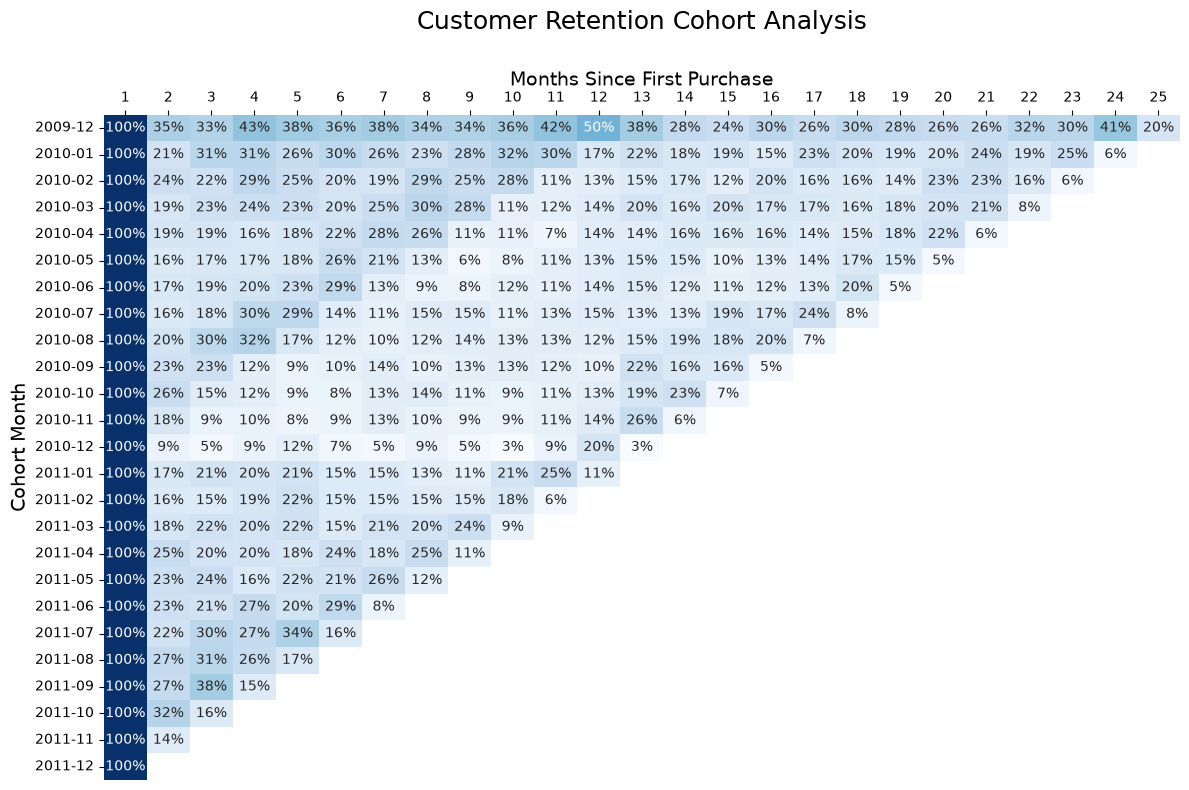

In [7]:
# 4. Visualize the Retention Rates
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
        retention,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        cbar=False
    )

plt.title('Customer Retention Cohort Analysis', pad=30, fontsize=18)
plt.ylabel('Cohort Month', fontsize=14)
plt.xlabel('Months Since First Purchase', fontsize=14)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.show()